In [ ]:
import time
import random
import pandas as pd
import numpy as np


# ============================================================
# Loader
# ============================================================

def load_ctx_drug(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    df.columns = df.columns.str.strip()
    df.index = df.index.astype(str).str.strip()
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


# ============================================================
# Pairwise tissue sets
# ============================================================

def pairwise_tissue_sets(df: pd.DataFrame):
    drugs = list(df.columns)
    tissues = list(df.index)
    n = len(drugs)

    S = [[set() for _ in range(n)] for __ in range(n)]
    vals = df.values

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            a = vals[:, i]
            b = vals[:, j]
            mask = (~np.isnan(a)) & (~np.isnan(b)) & (a > b)

            if np.any(mask):
                S[i][j] = {tissues[k] for k in np.flatnonzero(mask)}

    return drugs, tissues, S


# ============================================================
# CDR search on subset
# ============================================================

def cdr_search_subset(subset, drugs, S, lam):
    best_path = []
    best_S = set()

    adj = {
        i: [j for j in subset if i != j and len(S[i][j]) > 0]
        for i in subset
    }

    for start in subset:
        stack = [(start, [start], None)]

        while stack:
            cur, path, S_common = stack.pop()

            for nxt in adj[cur]:
                if nxt in path:
                    continue

                Sab = S[cur][nxt]
                newS = Sab if S_common is None else (S_common & Sab)

                if len(newS) >= lam:
                    new_path = path + [nxt]
                    stack.append((nxt, new_path, newS))

                    if len(new_path) > len(best_path):
                        best_path = new_path
                        best_S = set(newS)

    return best_path, best_S


# ============================================================
# Batch maker
# ============================================================

def make_batches(items, batch_size=40, seed=42):
    rng = random.Random(seed)
    items = items[:]
    rng.shuffle(items)
    return [items[i:i + batch_size] for i in range(0, len(items), batch_size)]


# ============================================================
# Partition-sensitivity experiment only
# Skips expensive final global search
# ============================================================

def run_partition_sensitivity_only(
    csv_path: str,
    lam: int = 30,
    batch_size: int = 40,
    seeds=None,
    max_passes: int = 6,
    save_csv: str = "coder_seed_partition_sensitivity.csv"
):
    if seeds is None:
        seeds = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

    print("Loading data...")
    df = load_ctx_drug(csv_path)

    print("Precomputing pairwise tissue sets once...")
    drugs, tissues, S = pairwise_tissue_sets(df)

    all_nodes = list(range(len(drugs)))
    rows = []

    for seed in seeds:
        t0 = time.time()

        print(f"\nRunning seed {seed}...")

        work_set = all_nodes[:]
        prev_size = len(work_set)

        pass_union_sizes = []
        pass_best_lengths = []
        pass_mean_lengths = []
        pass_num_batches = []

        for p in range(1, max_passes + 1):
            batches = make_batches(
                work_set,
                batch_size=batch_size,
                seed=seed + p - 1
            )

            union_set = set()
            batch_lengths = []

            for batch in batches:
                path, tset = cdr_search_subset(
                    subset=batch,
                    drugs=drugs,
                    S=S,
                    lam=lam
                )

                batch_lengths.append(len(path))

                if path and tset:
                    union_set.update(path)

            union_list = list(union_set)

            pass_union_sizes.append(len(union_list))
            pass_best_lengths.append(max(batch_lengths) if batch_lengths else 0)
            pass_mean_lengths.append(float(np.mean(batch_lengths)) if batch_lengths else 0)
            pass_num_batches.append(len(batches))

            if len(union_list) == 0:
                work_set = []
                break

            if len(union_list) <= batch_size:
                work_set = union_list
                break

            if len(union_list) >= prev_size:
                work_set = union_list
                break

            prev_size = len(union_list)
            work_set = union_list

        runtime = time.time() - t0

        row = {
            "seed": seed,
            "lambda": lam,
            "batch_size": batch_size,
            "max_passes": max_passes,
            "n_passes": len(pass_union_sizes),
            "initial_drug_count": len(all_nodes),
            "final_working_set_size": len(work_set),
            "pass_union_sizes": str(pass_union_sizes),
            "pass_best_lengths": str(pass_best_lengths),
            "pass_mean_lengths": str(pass_mean_lengths),
            "pass_num_batches": str(pass_num_batches),
            "runtime_s": runtime
        }

        rows.append(row)

        print(
            f"[seed={seed}] "
            f"final_working_set={len(work_set)} | "
            f"passes={len(pass_union_sizes)} | "
            f"union_sizes={pass_union_sizes} | "
            f"best_batch_lengths={pass_best_lengths} | "
            f"runtime={runtime:.3f}s"
        )

    results = pd.DataFrame(rows)
    results.to_csv(save_csv, index=False)

    print(f"\nSaved results to: {save_csv}")

    print("\nSummary of final working-set size:")
    print(results["final_working_set_size"].describe())

    print("\nSummary of runtime:")
    print(results["runtime_s"].describe())

    return results


# ============================================================
# Run
# ============================================================

partition_results = run_partition_sensitivity_only(
    csv_path="efficacy.csv",
    lam=30,
    batch_size=20,
    seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51],
    max_passes=6,
    save_csv="coder_seed_partition_sensitivity.csv"
)

Loading data...
Precomputing pairwise tissue sets once...

Running seed 42...
[seed=42] final_working_set=17 | passes=5 | union_sizes=[118, 60, 33, 23, 17] | best_batch_lengths=[10, 11, 11, 13, 14] | runtime=5.273s

Running seed 43...
[seed=43] final_working_set=18 | passes=5 | union_sizes=[120, 63, 37, 24, 18] | best_batch_lengths=[11, 12, 12, 12, 14] | runtime=4.339s

Running seed 44...
[seed=44] final_working_set=17 | passes=5 | union_sizes=[120, 58, 35, 22, 17] | best_batch_lengths=[11, 11, 12, 12, 15] | runtime=5.039s

Running seed 45...
[seed=45] final_working_set=13 | passes=5 | union_sizes=[119, 60, 34, 21, 13] | best_batch_lengths=[11, 11, 12, 12, 13] | runtime=5.198s

Running seed 46...
[seed=46] final_working_set=17 | passes=5 | union_sizes=[121, 60, 36, 23, 17] | best_batch_lengths=[10, 10, 12, 12, 14] | runtime=4.821s

Running seed 47...
[seed=47] final_working_set=16 | passes=5 | union_sizes=[118, 63, 37, 24, 16] | best_batch_lengths=[11, 12, 12, 13, 12] | runtime=5.336s


   seed  final_working_set_size  n_passes       pass_union_sizes  \
0    42                      17         5  [118, 60, 33, 23, 17]   
1    43                      18         5  [120, 63, 37, 24, 18]   
2    44                      17         5  [120, 58, 35, 22, 17]   
3    45                      13         5  [119, 60, 34, 21, 13]   
4    46                      17         5  [121, 60, 36, 23, 17]   
5    47                      16         5  [118, 63, 37, 24, 16]   
6    48                      18         5  [117, 57, 31, 23, 18]   
7    49                      18         5  [121, 62, 36, 25, 18]   
8    50                      14         5  [117, 57, 33, 21, 14]   
9    51                      20         4      [119, 59, 34, 20]   

     best_batch_lengths  runtime_s  
0  [10, 11, 11, 13, 14]      5.273  
1  [11, 12, 12, 12, 14]      4.339  
2  [11, 11, 12, 12, 15]      5.039  
3  [11, 11, 12, 12, 13]      5.198  
4  [10, 10, 12, 12, 14]      4.821  
5  [11, 12, 12, 13, 12]      

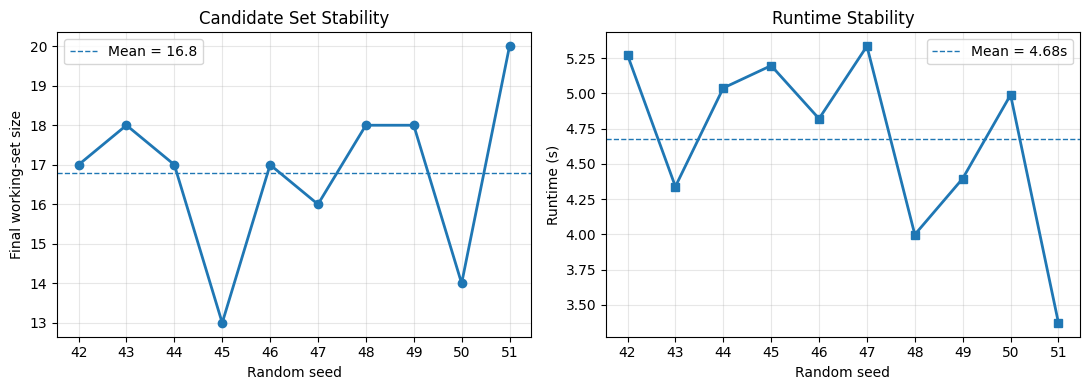

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    [42, 17, 5, "[118, 60, 33, 23, 17]", "[10, 11, 11, 13, 14]", 5.273],
    [43, 18, 5, "[120, 63, 37, 24, 18]", "[11, 12, 12, 12, 14]", 4.339],
    [44, 17, 5, "[120, 58, 35, 22, 17]", "[11, 11, 12, 12, 15]", 5.039],
    [45, 13, 5, "[119, 60, 34, 21, 13]", "[11, 11, 12, 12, 13]", 5.198],
    [46, 17, 5, "[121, 60, 36, 23, 17]", "[10, 10, 12, 12, 14]", 4.821],
    [47, 16, 5, "[118, 63, 37, 24, 16]", "[11, 12, 12, 13, 12]", 5.336],
    [48, 18, 5, "[117, 57, 31, 23, 18]", "[10, 10, 12, 14, 15]", 3.998],
    [49, 18, 5, "[121, 62, 36, 25, 18]", "[10, 11, 12, 13, 13]", 4.396],
    [50, 14, 5, "[117, 57, 33, 21, 14]", "[10, 11, 13, 11, 14]", 4.990],
    [51, 20, 4, "[119, 59, 34, 20]", "[10, 11, 12, 11]", 3.371],
]

df = pd.DataFrame(
    data,
    columns=[
        "seed",
        "final_working_set_size",
        "n_passes",
        "pass_union_sizes",
        "best_batch_lengths",
        "runtime_s"
    ]
)

df.to_csv("coder_seed_partition_sensitivity_hardcoded.csv", index=False)

print(df)
print("\nSummary:")
print(df[["final_working_set_size", "runtime_s"]].describe())


# =========================
# Figure: Seed sensitivity
# =========================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: final working-set size
axes[0].plot(
    df["seed"],
    df["final_working_set_size"],
    marker="o",
    linewidth=2
)

axes[0].axhline(
    df["final_working_set_size"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Mean = {df['final_working_set_size'].mean():.1f}"
)

axes[0].set_xlabel("Random seed")
axes[0].set_ylabel("Final working-set size")
axes[0].set_title("Candidate Set Stability")
axes[0].set_xticks(df["seed"])
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# Panel B: runtime
axes[1].plot(
    df["seed"],
    df["runtime_s"],
    marker="s",
    linewidth=2
)

axes[1].axhline(
    df["runtime_s"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Mean = {df['runtime_s'].mean():.2f}s"
)

axes[1].set_xlabel("Random seed")
axes[1].set_ylabel("Runtime (s)")
axes[1].set_title("Runtime Stability")
axes[1].set_xticks(df["seed"])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_seed_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import time
import random
import pandas as pd
import numpy as np


# ============================================================
# Loader
# ============================================================

def load_ctx_drug(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    df.columns = df.columns.str.strip()
    df.index = df.index.astype(str).str.strip()
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


# ============================================================
# Pairwise tissue sets
# ============================================================

def pairwise_tissue_sets(df: pd.DataFrame):
    drugs = list(df.columns)
    tissues = list(df.index)
    n = len(drugs)

    S = [[set() for _ in range(n)] for __ in range(n)]
    vals = df.values

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            a = vals[:, i]
            b = vals[:, j]
            mask = (~np.isnan(a)) & (~np.isnan(b)) & (a > b)

            if np.any(mask):
                S[i][j] = {tissues[k] for k in np.flatnonzero(mask)}

    return drugs, tissues, S


# ============================================================
# CDR search on subset
# ============================================================

def cdr_search_subset(subset, drugs, S, lam):
    best_path = []
    best_S = set()

    adj = {
        i: [j for j in subset if i != j and len(S[i][j]) > 0]
        for i in subset
    }

    for start in subset:
        stack = [(start, [start], None)]

        while stack:
            cur, path, S_common = stack.pop()

            for nxt in adj[cur]:
                if nxt in path:
                    continue

                Sab = S[cur][nxt]
                newS = Sab if S_common is None else (S_common & Sab)

                if len(newS) >= lam:
                    new_path = path + [nxt]
                    stack.append((nxt, new_path, newS))

                    if len(new_path) > len(best_path):
                        best_path = new_path
                        best_S = set(newS)

    return best_path, best_S


# ============================================================
# Batch maker
# ============================================================

def make_batches(items, batch_size=40, seed=42):
    rng = random.Random(seed)
    items = items[:]
    rng.shuffle(items)
    return [items[i:i + batch_size] for i in range(0, len(items), batch_size)]


# ============================================================
# Partition-sensitivity experiment only
# Skips expensive final global search
# ============================================================

def run_partition_sensitivity_only(
    csv_path: str,
    lam: int = 30,
    batch_size: int = 40,
    seeds=None,
    max_passes: int = 6,
    save_csv: str = "coder_seed_partition_sensitivity.csv"
):
    if seeds is None:
        seeds = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

    print("Loading data...")
    df = load_ctx_drug(csv_path)

    print("Precomputing pairwise tissue sets once...")
    drugs, tissues, S = pairwise_tissue_sets(df)

    all_nodes = list(range(len(drugs)))
    rows = []

    for seed in seeds:
        t0 = time.time()

        print(f"\nRunning seed {seed}...")

        work_set = all_nodes[:]
        prev_size = len(work_set)

        pass_union_sizes = []
        pass_best_lengths = []
        pass_mean_lengths = []
        pass_num_batches = []

        for p in range(1, max_passes + 1):
            batches = make_batches(
                work_set,
                batch_size=batch_size,
                seed=seed + p - 1
            )

            union_set = set()
            batch_lengths = []

            for batch in batches:
                path, tset = cdr_search_subset(
                    subset=batch,
                    drugs=drugs,
                    S=S,
                    lam=lam
                )

                batch_lengths.append(len(path))

                if path and tset:
                    union_set.update(path)

            union_list = list(union_set)

            pass_union_sizes.append(len(union_list))
            pass_best_lengths.append(max(batch_lengths) if batch_lengths else 0)
            pass_mean_lengths.append(float(np.mean(batch_lengths)) if batch_lengths else 0)
            pass_num_batches.append(len(batches))

            if len(union_list) == 0:
                work_set = []
                break

            if len(union_list) <= batch_size:
                work_set = union_list
                break

            if len(union_list) >= prev_size:
                work_set = union_list
                break

            prev_size = len(union_list)
            work_set = union_list

        runtime = time.time() - t0

        row = {
            "seed": seed,
            "lambda": lam,
            "batch_size": batch_size,
            "max_passes": max_passes,
            "n_passes": len(pass_union_sizes),
            "initial_drug_count": len(all_nodes),
            "final_working_set_size": len(work_set),
            "pass_union_sizes": str(pass_union_sizes),
            "pass_best_lengths": str(pass_best_lengths),
            "pass_mean_lengths": str(pass_mean_lengths),
            "pass_num_batches": str(pass_num_batches),
            "runtime_s": runtime
        }

        rows.append(row)

        print(
            f"[seed={seed}] "
            f"final_working_set={len(work_set)} | "
            f"passes={len(pass_union_sizes)} | "
            f"union_sizes={pass_union_sizes} | "
            f"best_batch_lengths={pass_best_lengths} | "
            f"runtime={runtime:.3f}s"
        )

    results = pd.DataFrame(rows)
    results.to_csv(save_csv, index=False)

    print(f"\nSaved results to: {save_csv}")

    print("\nSummary of final working-set size:")
    print(results["final_working_set_size"].describe())

    print("\nSummary of runtime:")
    print(results["runtime_s"].describe())

    return results


# ============================================================
# Run
# ============================================================

partition_results = run_partition_sensitivity_only(
    csv_path="efficacy.csv",
    lam=30,
    batch_size=35,
    seeds=[42, 43, 44, 45, 46, 47, 48, 49, 50, 51],
    max_passes=6,
    save_csv="coder_seed_partition_sensitivityv02.csv"
)

Loading data...
Precomputing pairwise tissue sets once...

Running seed 42...
[seed=42] final_working_set=21 | passes=3 | union_sizes=[86, 39, 21] | best_batch_lengths=[12, 15, 17] | runtime=534.959s

Running seed 43...
[seed=43] final_working_set=35 | passes=2 | union_sizes=[83, 35] | best_batch_lengths=[13, 14] | runtime=129.071s

Running seed 44...
[seed=44] final_working_set=16 | passes=3 | union_sizes=[83, 36, 16] | best_batch_lengths=[12, 14, 16] | runtime=417.857s

Running seed 45...
[seed=45] final_working_set=35 | passes=2 | union_sizes=[82, 35] | best_batch_lengths=[12, 15] | runtime=164.933s

Running seed 46...
[seed=46] final_working_set=35 | passes=2 | union_sizes=[81, 35] | best_batch_lengths=[12, 16] | runtime=154.158s

Running seed 47...
[seed=47] final_working_set=19 | passes=3 | union_sizes=[87, 38, 19] | best_batch_lengths=[12, 15, 16] | runtime=467.589s

Running seed 48...
[seed=48] final_working_set=18 | passes=3 | union_sizes=[83, 37, 18] | best_batch_lengths=[12,

   seed  batch_size  final_working_set_size  n_passes pass_union_sizes  \
0    42          35                      21         3     [86, 39, 21]   
1    43          35                      35         2         [83, 35]   
2    44          35                      16         3     [83, 36, 16]   
3    45          35                      35         2         [82, 35]   
4    46          35                      35         2         [81, 35]   
5    47          35                      19         3     [87, 38, 19]   
6    48          35                      18         3     [83, 37, 18]   
7    49          35                      34         2         [85, 34]   
8    50          35                      17         3     [84, 36, 17]   
9    51          35                      18         3     [87, 38, 18]   

  best_batch_lengths  runtime_s  
0       [12, 15, 17]    534.959  
1           [13, 14]    129.071  
2       [12, 14, 16]    417.857  
3           [12, 15]    164.933  
4           [12

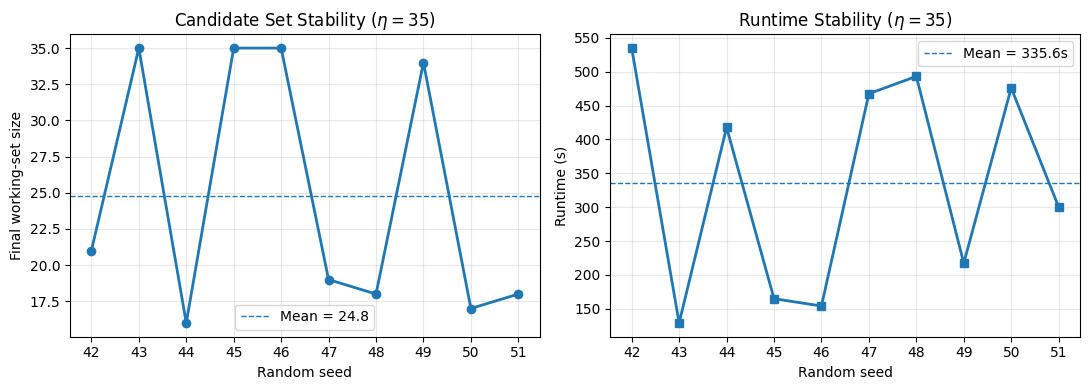

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    [42, 35, 21, 3, "[86, 39, 21]", "[12, 15, 17]", 534.959],
    [43, 35, 35, 2, "[83, 35]", "[13, 14]", 129.071],
    [44, 35, 16, 3, "[83, 36, 16]", "[12, 14, 16]", 417.857],
    [45, 35, 35, 2, "[82, 35]", "[12, 15]", 164.933],
    [46, 35, 35, 2, "[81, 35]", "[12, 16]", 154.158],
    [47, 35, 19, 3, "[87, 38, 19]", "[12, 15, 16]", 467.589],
    [48, 35, 18, 3, "[83, 37, 18]", "[12, 15, 16]", 493.176],
    [49, 35, 34, 2, "[85, 34]", "[12, 14]", 217.365],
    [50, 35, 17, 3, "[84, 36, 17]", "[12, 15, 17]", 476.093],
    [51, 35, 18, 3, "[87, 38, 18]", "[13, 14, 16]", 300.360],
]

df35 = pd.DataFrame(
    data,
    columns=[
        "seed",
        "batch_size",
        "final_working_set_size",
        "n_passes",
        "pass_union_sizes",
        "best_batch_lengths",
        "runtime_s"
    ]
)

df35.to_csv("coder_seed_partition_sensitivity_batch35.csv", index=False)

print(df35)

print("\nSummary:")
print(df35[["final_working_set_size", "runtime_s"]].describe())


# =========================
# Figure: Seed sensitivity for batch size 35
# =========================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: final working-set size
axes[0].plot(
    df35["seed"],
    df35["final_working_set_size"],
    marker="o",
    linewidth=2
)

axes[0].axhline(
    df35["final_working_set_size"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Mean = {df35['final_working_set_size'].mean():.1f}"
)

axes[0].set_xlabel("Random seed")
axes[0].set_ylabel("Final working-set size")
axes[0].set_title("Candidate Set Stability ($\\eta=35$)")
axes[0].set_xticks(df35["seed"])
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# Panel B: runtime
axes[1].plot(
    df35["seed"],
    df35["runtime_s"],
    marker="s",
    linewidth=2
)

axes[1].axhline(
    df35["runtime_s"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Mean = {df35['runtime_s'].mean():.1f}s"
)

axes[1].set_xlabel("Random seed")
axes[1].set_ylabel("Runtime (s)")
axes[1].set_title("Runtime Stability ($\\eta=35$)")
axes[1].set_xticks(df35["seed"])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_seed_sensitivity_batch35.png", dpi=300, bbox_inches="tight")
plt.show()

['seed', 'lambda', 'batch_size', 'max_passes', 'n_passes', 'initial_drug_count', 'final_working_set_size', 'pass_union_sizes', 'pass_best_lengths', 'pass_mean_lengths', 'pass_num_batches', 'runtime_s']


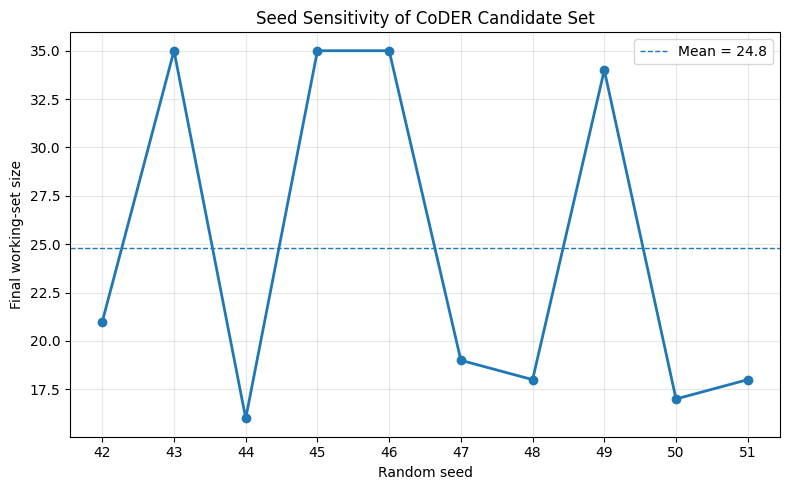

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("coder_seed_partition_sensitivityv02.csv")
df.columns = df.columns.str.strip()

print(df.columns.tolist())

plt.figure(figsize=(8, 5))

plt.plot(
    df["seed"],
    df["final_working_set_size"],
    marker="o",
    linewidth=2
)

plt.axhline(
    df["final_working_set_size"].mean(),
    linestyle="--",
    linewidth=1,
    label=f"Mean = {df['final_working_set_size'].mean():.1f}"
)

plt.xlabel("Random seed")
plt.ylabel("Final working-set size")
plt.title("Seed Sensitivity of CoDER Candidate Set")
plt.grid(True, alpha=0.3)
plt.xticks(df["seed"])
plt.legend()

plt.tight_layout()
plt.savefig("seed_vs_final_working_set_size.png", dpi=300)
plt.show()

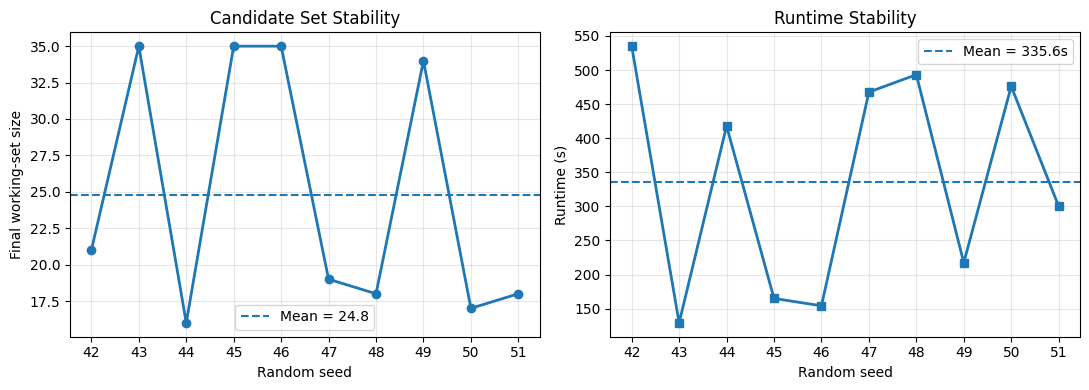

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("coder_seed_partition_sensitivityv02.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(df["seed"], df["final_working_set_size"], marker="o", linewidth=2)
axes[0].axhline(df["final_working_set_size"].mean(), linestyle="--",
                label=f"Mean = {df['final_working_set_size'].mean():.1f}")
axes[0].set_xlabel("Random seed")
axes[0].set_ylabel("Final working-set size")
axes[0].set_title("Candidate Set Stability")
axes[0].set_xticks(df["seed"])
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df["seed"], df["runtime_s"], marker="s", linewidth=2)
axes[1].axhline(df["runtime_s"].mean(), linestyle="--",
                label=f"Mean = {df['runtime_s'].mean():.1f}s")
axes[1].set_xlabel("Random seed")
axes[1].set_ylabel("Runtime (s)")
axes[1].set_title("Runtime Stability")
axes[1].set_xticks(df["seed"])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("seed_sensitivity_partition_stage.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import time
import random
import ast
import pandas as pd
import numpy as np


# ============================================================
# Loader
# ============================================================

def load_ctx_drug(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    df.columns = df.columns.str.strip()
    df.index = df.index.astype(str).str.strip()
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


# ============================================================
# Pairwise tissue sets
# ============================================================

def pairwise_tissue_sets(df: pd.DataFrame):
    drugs = list(df.columns)
    tissues = list(df.index)
    n = len(drugs)
    vals = df.values

    S = [[set() for _ in range(n)] for __ in range(n)]

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            a = vals[:, i]
            b = vals[:, j]

            mask = (~np.isnan(a)) & (~np.isnan(b)) & (a > b)

            if np.any(mask):
                S[i][j] = {tissues[k] for k in np.flatnonzero(mask)}

    return drugs, tissues, S


# ============================================================
# Subset CDR search using cached S
# ============================================================

def cdr_search_subset(subset, drugs, S, lam):
    best_path = []
    best_S = set()

    adj = {
        i: [j for j in subset if i != j and len(S[i][j]) > 0]
        for i in subset
    }

    for start in subset:
        stack = [(start, [start], None)]

        while stack:
            cur, path, S_common = stack.pop()

            for nxt in adj[cur]:
                if nxt in path:
                    continue

                Sab = S[cur][nxt]
                newS = Sab if S_common is None else S_common & Sab

                if len(newS) >= lam:
                    new_path = path + [nxt]
                    stack.append((nxt, new_path, newS))

                    if len(new_path) > len(best_path):
                        best_path = new_path[:]
                        best_S = set(newS)

    return best_path, best_S


# ============================================================
# Batch maker
# ============================================================

def make_batches(items, batch_size, seed):
    rng = random.Random(seed)
    items = items[:]
    rng.shuffle(items)
    return [items[i:i + batch_size] for i in range(0, len(items), batch_size)]


# ============================================================
# Final length extension using cached S
# ============================================================

def extend_order_cached(order, tset, all_nodes, S):
    if len(order) < 2 or not tset:
        return order[:]

    cur = order[:]
    changed = True

    while changed:
        changed = False
        i = 0

        while i < len(cur) - 1:
            A, B = cur[i], cur[i + 1]

            candidates = [x for x in all_nodes if x not in cur]
            insertables = []

            for X in candidates:
                if tset.issubset(S[A][X]) and tset.issubset(S[X][B]):
                    insertables.append(X)

            if insertables:
                insertables.sort(
                    key=lambda x: min(len(S[A][x]), len(S[x][B])),
                    reverse=True
                )

                for X in insertables:
                    cur.insert(i + 1, X)
                    changed = True
                    i += 1

            i += 1

    return cur


# ============================================================
# Phase 1: Partition-only seed sensitivity
# ============================================================

def run_partition_only(
    drugs,
    S,
    lam,
    batch_size,
    seed,
    max_passes=6
):
    t0 = time.time()

    all_nodes = list(range(len(drugs)))
    work_set = all_nodes[:]
    prev_size = len(work_set)

    pass_union_sizes = []
    pass_best_lengths = []
    pass_mean_lengths = []
    pass_num_batches = []

    for p in range(1, max_passes + 1):
        batches = make_batches(
            work_set,
            batch_size=batch_size,
            seed=seed + p - 1
        )

        union_set = set()
        batch_lengths = []

        for batch in batches:
            path, tset = cdr_search_subset(
                subset=batch,
                drugs=drugs,
                S=S,
                lam=lam
            )

            batch_lengths.append(len(path))

            if path and tset:
                union_set.update(path)

        union_list = list(union_set)

        pass_union_sizes.append(len(union_list))
        pass_best_lengths.append(max(batch_lengths) if batch_lengths else 0)
        pass_mean_lengths.append(float(np.mean(batch_lengths)) if batch_lengths else 0.0)
        pass_num_batches.append(len(batches))

        if len(union_list) == 0:
            work_set = []
            break

        if len(union_list) <= batch_size:
            work_set = union_list
            break

        if len(union_list) >= prev_size:
            work_set = union_list
            break

        prev_size = len(union_list)
        work_set = union_list

    runtime = time.time() - t0

    return {
        "seed": seed,
        "batch_size": batch_size,
        "lambda": lam,
        "max_passes": max_passes,
        "n_passes": len(pass_union_sizes),
        "initial_drug_count": len(all_nodes),
        "final_working_set_size": len(work_set),
        "pass_union_sizes": pass_union_sizes,
        "pass_best_lengths": pass_best_lengths,
        "pass_mean_lengths": pass_mean_lengths,
        "pass_num_batches": pass_num_batches,
        "runtime_s": runtime
    }


# ============================================================
# Phase 2: Full CoDER for selected seeds
# ============================================================

def run_full_coder_cached(
    drugs,
    S,
    lam,
    batch_size,
    seed,
    max_passes=6
):
    t0 = time.time()

    all_nodes = list(range(len(drugs)))
    work_set = all_nodes[:]
    prev_size = len(work_set)

    pass_union_sizes = []
    pass_best_lengths = []
    pass_mean_lengths = []
    pass_num_batches = []

    for p in range(1, max_passes + 1):
        batches = make_batches(
            work_set,
            batch_size=batch_size,
            seed=seed + p - 1
        )

        union_set = set()
        batch_lengths = []

        for batch in batches:
            path, tset = cdr_search_subset(
                subset=batch,
                drugs=drugs,
                S=S,
                lam=lam
            )

            batch_lengths.append(len(path))

            if path and tset:
                union_set.update(path)

        union_list = list(union_set)

        pass_union_sizes.append(len(union_list))
        pass_best_lengths.append(max(batch_lengths) if batch_lengths else 0)
        pass_mean_lengths.append(float(np.mean(batch_lengths)) if batch_lengths else 0.0)
        pass_num_batches.append(len(batches))

        if len(union_list) == 0:
            work_set = []
            break

        if len(union_list) <= batch_size:
            work_set = union_list
            break

        if len(union_list) >= prev_size:
            work_set = union_list
            break

        prev_size = len(union_list)
        work_set = union_list

    # Global search
    if len(work_set) < 2:
        global_path = work_set[:]
        global_tset = set()
        final_path = work_set[:]
    else:
        global_path, global_tset = cdr_search_subset(
            subset=work_set,
            drugs=drugs,
            S=S,
            lam=lam
        )

        final_path = extend_order_cached(
            order=global_path,
            tset=global_tset,
            all_nodes=all_nodes,
            S=S
        )

    runtime = time.time() - t0

    return {
        "seed": seed,
        "batch_size": batch_size,
        "lambda": lam,
        "max_passes": max_passes,
        "n_passes": len(pass_union_sizes),
        "initial_drug_count": len(all_nodes),
        "final_working_set_size": len(work_set),
        "global_path_length": len(global_path),
        "final_path_length": len(final_path),
        "support_size": len(global_tset),
        "runtime_s": runtime,
        "pass_union_sizes": pass_union_sizes,
        "pass_best_lengths": pass_best_lengths,
        "pass_mean_lengths": pass_mean_lengths,
        "pass_num_batches": pass_num_batches,
        "global_order": " > ".join([drugs[i] for i in global_path]),
        "final_order": " > ".join([drugs[i] for i in final_path])
    }


# ============================================================
# Utility: convert list columns to strings for CSV
# ============================================================

def serialize_list_columns(df, list_cols):
    df = df.copy()
    for col in list_cols:
        df[col] = df[col].apply(lambda x: str(x))
    return df


# ============================================================
# Main experiment runner
# ============================================================

def run_seed_sensitivity_experiment(
    csv_path="efficacy.csv",
    lam=30,
    batch_sizes=(20, 35, 40),
    seeds=(42, 43, 44, 45, 46, 47, 48, 49, 50, 51),
    selected_full_seeds=(42, 43, 45, 48, 51),
    max_passes=6
):
    print("Loading data...")
    df = load_ctx_drug(csv_path)

    print("Precomputing pairwise tissue sets once...")
    drugs, tissues, S = pairwise_tissue_sets(df)

    print(f"Number of drugs: {len(drugs)}")
    print(f"Number of tissues: {len(tissues)}")

    # --------------------------------------------------------
    # Phase 1: partition-only for all batch sizes/seeds
    # --------------------------------------------------------

    partition_rows = []

    for batch_size in batch_sizes:
        print(f"\n=== Partition-only experiment | batch_size={batch_size} ===")

        for seed in seeds:
            out = run_partition_only(
                drugs=drugs,
                S=S,
                lam=lam,
                batch_size=batch_size,
                seed=seed,
                max_passes=max_passes
            )

            partition_rows.append(out)

            print(
                f"batch={batch_size} | seed={seed} | "
                f"final_working_set={out['final_working_set_size']} | "
                f"passes={out['n_passes']} | "
                f"runtime={out['runtime_s']:.3f}s"
            )

    partition_df = pd.DataFrame(partition_rows)

    partition_df_csv = serialize_list_columns(
        partition_df,
        [
            "pass_union_sizes",
            "pass_best_lengths",
            "pass_mean_lengths",
            "pass_num_batches"
        ]
    )

    partition_df_csv.to_csv("partition_sensitivity_all_batches.csv", index=False)

    # --------------------------------------------------------
    # Phase 2: full CoDER only for selected seeds
    # --------------------------------------------------------

    full_rows = []

    for batch_size in batch_sizes:
        print(f"\n=== Full CoDER selected seeds | batch_size={batch_size} ===")

        for seed in selected_full_seeds:
            out = run_full_coder_cached(
                drugs=drugs,
                S=S,
                lam=lam,
                batch_size=batch_size,
                seed=seed,
                max_passes=max_passes
            )

            full_rows.append(out)

            print(
                f"batch={batch_size} | seed={seed} | "
                f"final_path={out['final_path_length']} | "
                f"support={out['support_size']} | "
                f"work_set={out['final_working_set_size']} | "
                f"runtime={out['runtime_s']:.3f}s"
            )

    full_df = pd.DataFrame(full_rows)

    full_df_csv = serialize_list_columns(
        full_df,
        [
            "pass_union_sizes",
            "pass_best_lengths",
            "pass_mean_lengths",
            "pass_num_batches"
        ]
    )

    full_df_csv.to_csv("full_coder_selected_seeds.csv", index=False)

    # --------------------------------------------------------
    # Summary table
    # --------------------------------------------------------

    partition_summary = (
        partition_df
        .groupby("batch_size")
        .agg(
            n_runs=("seed", "count"),
            mean_final_working_set=("final_working_set_size", "mean"),
            std_final_working_set=("final_working_set_size", "std"),
            min_final_working_set=("final_working_set_size", "min"),
            max_final_working_set=("final_working_set_size", "max"),
            mean_partition_runtime_s=("runtime_s", "mean"),
            std_partition_runtime_s=("runtime_s", "std")
        )
        .reset_index()
    )

    full_summary = (
        full_df
        .groupby("batch_size")
        .agg(
            n_full_runs=("seed", "count"),
            mean_final_path_length=("final_path_length", "mean"),
            std_final_path_length=("final_path_length", "std"),
            min_final_path_length=("final_path_length", "min"),
            max_final_path_length=("final_path_length", "max"),
            mean_support_size=("support_size", "mean"),
            std_support_size=("support_size", "std"),
            mean_full_runtime_s=("runtime_s", "mean"),
            std_full_runtime_s=("runtime_s", "std")
        )
        .reset_index()
    )

    summary_df = partition_summary.merge(
        full_summary,
        on="batch_size",
        how="left"
    )

    summary_df.to_csv("seed_sensitivity_summary.csv", index=False)

    print("\nSaved files:")
    print("- partition_sensitivity_all_batches.csv")
    print("- full_coder_selected_seeds.csv")
    print("- seed_sensitivity_summary.csv")

    print("\nSummary:")
    print(summary_df)

    return partition_df, full_df, summary_df


# ============================================================
# Run experiment
# ============================================================

partition_df, full_df, summary_df = run_seed_sensitivity_experiment(
    csv_path="efficacy.csv",
    lam=30,
    batch_sizes=(20, 35, 40),
    seeds=(42, 43, 44, 45, 46, 47, 48, 49, 50, 51),
    selected_full_seeds=(42, 43, 45, 48, 51),
    max_passes=6
)

Loading data...
Precomputing pairwise tissue sets once...
Number of drugs: 273
Number of tissues: 49

=== Partition-only experiment | batch_size=20 ===
batch=20 | seed=42 | final_working_set=17 | passes=5 | runtime=5.706s
batch=20 | seed=43 | final_working_set=18 | passes=5 | runtime=4.272s
batch=20 | seed=44 | final_working_set=17 | passes=5 | runtime=4.579s
batch=20 | seed=45 | final_working_set=13 | passes=5 | runtime=5.692s
batch=20 | seed=46 | final_working_set=17 | passes=5 | runtime=4.777s
batch=20 | seed=47 | final_working_set=16 | passes=5 | runtime=4.620s
batch=20 | seed=48 | final_working_set=18 | passes=5 | runtime=4.572s
batch=20 | seed=49 | final_working_set=18 | passes=5 | runtime=4.303s
batch=20 | seed=50 | final_working_set=14 | passes=5 | runtime=5.087s
batch=20 | seed=51 | final_working_set=20 | passes=4 | runtime=3.695s

=== Partition-only experiment | batch_size=35 ===
batch=35 | seed=42 | final_working_set=21 | passes=3 | runtime=529.558s
batch=35 | seed=43 | fina